# Cuaderno de prueba para descarga de imágenes de GEE

In [1]:
!pip install earthengine-api requests rasterio matplotlib

   ---------------------------------------- 0.0/30.1 MB ? eta -:--:--
   -- ------------------------------------- 1.6/30.1 MB 7.1 MB/s eta 0:00:05
   ---- ----------------------------------- 3.1/30.1 MB 7.3 MB/s eta 0:00:04
   ------ --------------------------------- 4.7/30.1 MB 7.3 MB/s eta 0:00:04
   -------- ------------------------------- 6.0/30.1 MB 7.3 MB/s eta 0:00:04
   ---------- ----------------------------- 7.6/30.1 MB 7.1 MB/s eta 0:00:04
   ------------ --------------------------- 9.2/30.1 MB 7.3 MB/s eta 0:00:03
   -------------- ------------------------- 11.0/30.1 MB 7.4 MB/s eta 0:00:03
   ---------------- ----------------------- 12.6/30.1 MB 7.4 MB/s eta 0:00:03
   ------------------ --------------------- 14.2/30.1 MB 7.5 MB/s eta 0:00:03
   -------------------- ------------------- 15.7/30.1 MB 7.5 MB/s eta 0:00:02
   ---------------------- ----------------- 17.3/30.1 MB 7.6 MB/s eta 0:00:02
   ------------------------- -------------- 18.9/30.1 MB 7.6 MB/s eta 0:00:02


In [ ]:
import ee

# La primera vez se abrirá el flujo de autenticación.
# Modo 'notebook'.
ee.Authenticate(auth_mode='notebook')

# Project ID de Google Cloud
PROJECT_ID = "golden-tide-482516-f7"
ee.Initialize(project=PROJECT_ID)

print("Earth Engine inicializado correctamente")

Enter verification code:  4/1AfrIepAh-QR6RnkYQiClqyF2pVAgqYFQbWeWs-xark_2IEYbUYjIfwmjtSU



Successfully saved authorization token.
Earth Engine inicializado correctamente


In [3]:
print(ee.Number(1).add(1).getInfo())

2


In [4]:
# Coordenada aproximada inspirada en una de las del artículo
lon, lat = -5.5012, 43.0270

point = ee.Geometry.Point([lon, lat])

# Cuadrado pequeño (~120 m x 120 m) para una prueba rápida
aoi = point.buffer(60).bounds()

In [5]:
import requests

collection = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(aoi)
    .filterDate("2024-06-01", "2024-09-30")
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 10))
    .sort("CLOUDY_PIXEL_PERCENTAGE")
)

image = ee.Image(collection.first()).select(["B4", "B3", "B2"]).clip(aoi)

print("Bandas:", image.bandNames().getInfo())
print("Fecha escena:", ee.Date(image.get("system:time_start")).format("YYYY-MM-dd").getInfo())

url = image.getDownloadURL({
    "region": aoi,
    "scale": 10,
    "format": "GEO_TIFF",
    "filePerBand": False,
    "name": "gee_prueba_rgb"
})

print(url)

Bandas: ['B4', 'B3', 'B2']
Fecha escena: 2024-08-16
https://earthengine.googleapis.com/v1/projects/golden-tide-482516-f7/thumbnails/b66929b4269cdc565517a88f16300206-1cb405a95c0be0d63ac4fa12a5fbc596:getPixels


In [6]:
out_path = "gee_prueba_rgb.tif"

r = requests.get(url, stream=True, timeout=120)
r.raise_for_status()

with open(out_path, "wb") as f:
    for chunk in r.iter_content(chunk_size=8192):
        if chunk:
            f.write(chunk)

print(f"Archivo guardado en: {out_path}")

Archivo guardado en: gee_prueba_rgb.tif


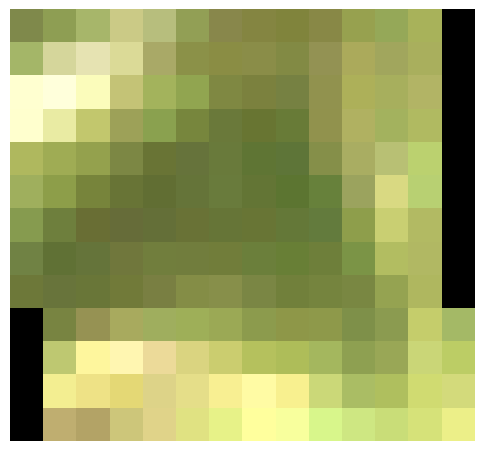

In [7]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

with rasterio.open("gee_prueba_rgb.tif") as src:
    data = src.read()  # shape: (bands, rows, cols)

rgb = np.transpose(data, (1, 2, 0)).astype(np.float32)

# Escalado simple para visualizar
rgb = rgb / np.percentile(rgb, 98)
rgb = np.clip(rgb, 0, 1)

plt.figure(figsize=(6, 6))
plt.imshow(rgb)
plt.axis("off")
plt.show()

In [8]:
with rasterio.open("gee_prueba_rgb.tif") as src:
    print("Bandas:", src.count)
    print("Tamaño:", src.width, "x", src.height)
    print("CRS:", src.crs)
    print("NoData:", src.nodata)
    print("Bounds:", src.bounds)
    print("Tipo:", src.dtypes)

Bandas: 3
Tamaño: 14 x 13
CRS: EPSG:32629
NoData: 0.0
Bounds: BoundingBox(left=785000.0, bottom=4769690.0, right=785140.0, top=4769820.0)
Tipo: ('uint16', 'uint16', 'uint16')


## Visualización de QGIS

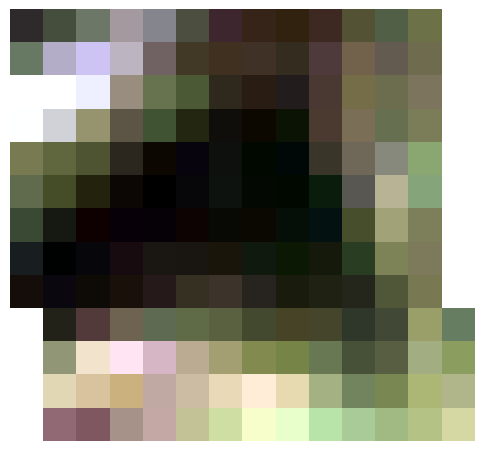

In [9]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

with rasterio.open("gee_prueba_rgb.tif") as src:
    data = src.read().astype(np.float32)  # (3, h, w)

rgb = np.transpose(data, (1, 2, 0))  # (h, w, 3)

# Píxeles válidos: al menos una banda distinta de 0
valid = np.any(rgb != 0, axis=2)

# Estirado por banda usando solo píxeles válidos
rgb_scaled = rgb.copy()
for i in range(3):
    band = rgb[..., i]
    vals = band[valid]
    if len(vals) > 0:
        p2, p98 = np.percentile(vals, (2, 98))
        if p98 > p2:
            rgb_scaled[..., i] = np.clip((band - p2) / (p98 - p2), 0, 1)
        else:
            rgb_scaled[..., i] = 0

# Los NoData como transparente/blanco visual
rgb_scaled[~valid] = np.nan

plt.figure(figsize=(6, 6))
plt.imshow(rgb_scaled)
plt.axis("off")
plt.show()